# Non-Homologous TARDIS Workflow

In [1]:
from numba import config as nbconfig

nbconfig.DISABLE_JIT = False

In [2]:
import matplotlib.pyplot as plt

from tardis.io.configuration.config_reader import Configuration
from tardis.workflows.nonhomologous_tardis_workflow import (
    NonhomologousTARDISWorkflow,
)
from tardis.workflows.simple_tardis_workflow import SimpleTARDISWorkflow


Iterations:          0/? [00:00<?, ?it/s]

Packets:             0/? [00:00<?, ?it/s]

Initializing tabulator and plotly panel extensions for widgets to work


Auto-detected Sphinx build environment


Auto-detected Sphinx build environment


In [3]:
config = Configuration.from_yaml('../tardis_example.yml')
config.montecarlo['enable_full_relativity'] = False

In [4]:
workflow = NonhomologousTARDISWorkflow(config)
hom_workflow = SimpleTARDISWorkflow(config)

HTML(str, height=10, sizing_mode='stretch_width', styles={'border': '1px solid #ddd...})

HTML(str, height=10, sizing_mode='stretch_width', styles={'border': '1px solid #ddd...})

In [5]:
workflow.run()

In [6]:
hom_workflow.run()

In [7]:
spectrum = workflow.spectrum_solver.spectrum_real_packets
spectrum_virtual = workflow.spectrum_solver.spectrum_virtual_packets
spectrum_integrated = workflow.spectrum_solver.spectrum_integrated
hom_spectrum = hom_workflow.spectrum_solver.spectrum_real_packets
hom_spectrum_virtual = hom_workflow.spectrum_solver.spectrum_virtual_packets
hom_spectrum_integrated = workflow.spectrum_solver.spectrum_integrated

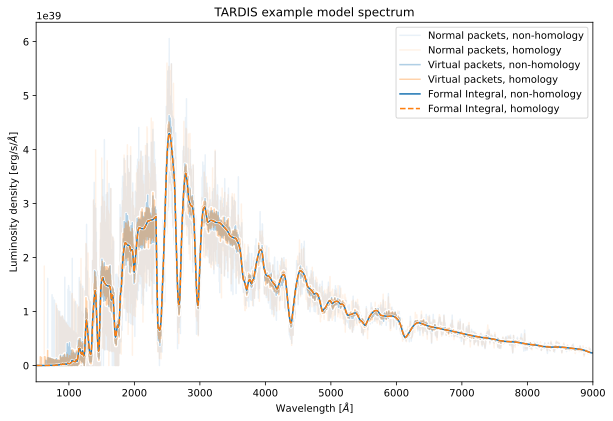

In [8]:
%matplotlib inline
plt.figure(figsize=(10, 6.5))

spectrum.plot(label="Normal packets, non-homology", c='C0', alpha=0.1)
hom_spectrum.plot(label="Normal packets, homology", c='C1', alpha=0.1)

spectrum_virtual.plot(linewidth=3, c='w', alpha=1.0)
hom_spectrum_virtual.plot(linewidth=4, c='w', alpha=1.0)
spectrum_virtual.plot(label="Virtual packets, non-homology", c='C0', alpha=0.35)
hom_spectrum_virtual.plot(label="Virtual packets, homology", c='C1', alpha=0.35)

spectrum_integrated.plot(linewidth=3, c='w', alpha=1.0)
spectrum_integrated.plot(label="Formal Integral, non-homology", c='C0', alpha=1.0)
hom_spectrum_integrated.plot(label="Formal Integral, homology", c='C1', alpha=1.0, linestyle='--')


plt.xlim(500, 9000)
plt.title("TARDIS example model spectrum")
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"Luminosity density [erg/s/$\AA$]")
plt.legend()
plt.show()